# 02 · A simple cross-sectional momentum strategy

**Research question:** Does a simple cross-sectional momentum rule applied to the existing 50-company universe produce different historical return and risk characteristics from SPY?

This notebook builds one historical experiment, checks its timing, and explains its results. It uses the frozen adjusted prices already verified in notebook 01. Run all cells from a fresh kernel. The calculations in Python are the financial source of truth for the website. This is educational research, not a forecast or a recommendation.

## 2. Strategy definition — fixed before evaluation

- Use the same 50 selected companies as notebook 01. ETFs are not candidates.
- At each completed month-end, measure adjusted-price total return over the preceding **12 months**, including the most recent month: `P[t] / P[t−12] − 1`.
- Require all 13 month-end prices and every daily quote between the two endpoints to be present and positive. Newly listed companies wait for a complete lookback.
- Rank eligible companies by that signal, highest first; break exact ties alphabetically by ticker. Select exactly **10**, each at **10%** of capital.
- Assume frictionless allocation at the formation close. Earn only the **following month's** returns, holding fixed adjusted units until the next rebalance. Weights drift within the month.
- Begin the reported comparison at the first formation close where ten companies and SPY are available. Do not shorten the sample based on future holding returns.
- No costs, taxes, slippage, leverage, short positions, alternative settings, or parameter search.

A closing price is only fully known at the close. Using that same close for allocation is an idealized monthly execution assumption, not proof of a fill an investor could obtain. We prevent future-return leakage; we do not model order submission or auction execution.

## 3. Why test momentum?

Momentum asks whether relative historical winners subsequently behave differently from a benchmark. “Cross-sectional” means ranking companies against one another on each date, rather than predicting an absolute price.

Past-return rankings are established research objects. For context, [Kenneth French's momentum documentation](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_mom_factor_daily.html) describes a different construction using prior months 2–12. This notebook follows the requested full 12-month, long-only top-ten rule; it does not replicate that factor or test skip-month variants. One result in a selected surviving universe cannot establish a general momentum premium.

## 4. Data and universe

The loader validates the frozen cache's hashes, symbols, dates, and adjustment settings. It never requests live data. Adjusted Close incorporates the provider's split and distribution adjustments; it is a total-return proxy, not a reconstruction of trades or cash dividends. The company list is read from notebook 01 so it cannot silently diverge.

Reusable functions live in `scripts/momentum_research.py`; their complete source is available beside this notebook. Each step below states its inputs, formula, and output.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'scripts').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scripts.market_data import load_market_inputs, universe_from_notebook
from scripts.momentum_research import (
    month_end_prices, momentum_signals, select_weights, backtest,
    performance_summary, calendar_returns,
)
from scripts.research_checks import wealth_from_returns, previous_observation
from scripts.momentum_outputs import write_outputs

pd.set_option('display.max_columns', 12)
plt.rcParams.update({'figure.figsize': (11, 4.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.2})
tickers = universe_from_notebook()
companies = tickers[5:]
prices, cached_rf, input_manifest = load_market_inputs(tickers)
assert len(companies) == 50 and not set(companies) & set(tickers[:5])
display(pd.Series({'companies': len(companies), 'cached_first_date': str(prices.index[0].date()),
                   'cached_last_date': str(prices.index[-1].date()),
                   'acquired_at': input_manifest['acquired_at']}))
print(', '.join(companies))

companies                                          50
cached_first_date                          1980-01-02
cached_last_date                           2026-09-10
acquired_at          2026-09-11T10:23:34.223001+00:00
dtype: object

AAPL, MSFT, NVDA, AVGO, ORCL, CRM, CSCO, IBM, AMD, QCOM, TXN, INTU, NOW, GOOGL, META, NFLX, DIS, AMZN, TSLA, WMT, COST, HD, MCD, NKE, BKNG, JPM, BAC, GS, MS, AXP, V, MA, BRK-B, LLY, JNJ, ABBV, UNH, TMO, ABT, AMGN, XOM, CVX, GE, CAT, RTX, PG, KO, PEP, PM, LIN


## 5. Monthly price construction

Take the exact final observed date of each completed calendar month on the frozen daily grid. Read every company's price on that same row. We do **not** use a last-nonmissing-price operation: that could silently substitute a stale quote. The final cached month is still in progress and is not a new signal date; its observed days can be evaluated using the preceding month's signal.

In [2]:
monthly = month_end_prices(prices[companies])
assert monthly.index.to_period('M').is_unique
assert monthly.index[-1].to_period('M') < prices.index[-1].to_period('M')
display(monthly.tail(3))

,AAPL,MSFT,NVDA,AVGO,ORCL,CRM,...,RTX,PG,KO,PEP,PM,LIN
Date,,,,,,,,,,,,,
2026-06-30,289.110657,372.319092,199.866348,377.750000,146.041931,156.660004,...,189.101807,145.553436,81.269997,133.968826,180.910004,517.236633
2026-07-31,308.643829,463.846802,200.525620,389.279999,129.869995,184.020004,...,214.507416,144.490005,87.589996,138.084854,190.820007,476.809784
2026-08-31,316.850006,507.290009,220.533234,370.339996,149.119995,257.540009,...,207.729996,145.119995,88.669998,138.856613,187.300003,487.972992


## 6. Signal construction

The denominator is the same month-end twelve calendar months earlier, not twelve daily observations earlier. Thirteen endpoints span twelve monthly intervals. Missing history produces no signal; it never becomes zero momentum. Eligibility checks only rows ending on the formation date.

In [3]:
signals = momentum_signals(monthly, prices[companies])
assert signals.iloc[:12].isna().all().all()
# One visible formula check, independent of the helper.
check_date = monthly.index[-1]
lookback_date = monthly.index[-13]
raw_signal = prices.loc[check_date, companies] / prices.loc[lookback_date, companies] - 1
np.testing.assert_allclose(signals.loc[check_date].dropna(),
                           raw_signal.loc[signals.loc[check_date].dropna().index])
display(signals.tail(3))

,AAPL,MSFT,NVDA,AVGO,ORCL,CRM,...,RTX,PG,KO,PEP,PM,LIN
Date,,,,,,,,,,,,,
2026-06-30,0.415938,-0.244085,0.268159,0.380438,-0.322964,-0.420639,...,0.320051,-0.053111,0.181224,0.066047,0.029275,0.120946
2026-07-31,0.494125,-0.121964,0.130136,0.335146,-0.482405,-0.281626,...,0.387637,-0.011504,0.326714,0.051954,0.205308,0.053360
2026-08-31,0.369951,0.009422,0.269228,0.254425,-0.333040,0.013541,...,0.329214,-0.048730,0.321658,-0.018524,0.161272,0.037384


## 7. Ranking and selection

Every nonzero target weight is 0.1. When fewer than ten companies qualify, no allocation is formed. The full signal table includes eligible companies that were not selected, so the ranking can be audited.

In [4]:
weights, holdings = select_weights(signals)
invested = weights.sum(axis=1) > 0
np.testing.assert_allclose(weights.loc[invested].sum(axis=1), 1)
assert (weights.loc[invested].gt(0).sum(axis=1) == 10).all()
assert not holdings.duplicated(['rebalance_date', 'ticker']).any()
print('First signal with ten eligible companies:', weights.index[invested][0].date())
display(holdings.tail(10))

First signal with ten eligible companies: 1981-01-30


,rebalance_date,ticker,rank,signal,weight
5470,2026-08-31,AMD,1,1.894423,0.1
5471,2026-08-31,CAT,2,0.920219,0.1
5472,2026-08-31,CSCO,3,0.632333,0.1
5473,2026-08-31,GOOGL,4,0.598413,0.1
5474,2026-08-31,LLY,5,0.588939,0.1
5475,2026-08-31,AMGN,6,0.535591,0.1
5476,2026-08-31,JNJ,7,0.534352,0.1
5477,2026-08-31,MS,8,0.449733,0.1
5478,2026-08-31,XOM,9,0.449075,0.1
5479,2026-08-31,GS,10,0.396819,0.1


## 8. Preventing look-ahead bias

Read the timeline from left to right: **past prices → formation-date rank → target weights → following-month holding returns**. The selection function receives only signals, never subsequent returns. A company is not removed because its next month is bad or incomplete.

The tests perturb prices after a formation date and compare the historical signals and holdings. They also truncate the dataset after that date, check that an IPO cannot qualify immediately, and create an extreme future winner to ensure it cannot enter an earlier selection. These checks address temporal leakage. They cannot remove survivorship bias in the present-day company list.

In [5]:
# Holdings for the next calendar month come from the previous month-end.
timing = pd.DataFrame({'signal_date': weights.index[invested]})
timing['holding_month'] = (timing['signal_date'].dt.to_period('M') + 1).astype(str)
assert (timing['signal_date'].dt.to_period('M').astype(str) < timing['holding_month']).all()
display(timing.head())

,signal_date,holding_month
0,1981-01-30,1981-02
1,1981-02-27,1981-03
2,1981-03-31,1981-04
3,1981-04-30,1981-05
4,1981-05-29,1981-06


## 9. Portfolio return construction

For selected company i in holding month m, its value relative to the formation close is `0.1 × P[i,d] / P[i,formation]`. Sum the ten position values to get within-month portfolio wealth. Daily portfolio return is today's wealth divided by yesterday's wealth minus one, starting that month from 1. This gives monthly rebalancing; applying 10% to each daily return instead would imply daily rebalancing.

**Missing held price policy:** at the first missing, nonfinite, or nonpositive quote, write that position's remaining value down to zero and keep it at zero through month-end, even if a quote returns. It may qualify at a future formation only after a new complete history. This deliberately severe fallback is not a claimed delisting return. It avoids a fictitious flat return or a hindsight replacement. Missing SPY prices, a fully lost portfolio, or insufficient eligibility after inception stop the run rather than silently dropping dates.

In [6]:
returns, rebalances, end_weights, missing_events = backtest(prices, weights)
initial_date = rebalances.index[0]
# Retain only holdings used in the common strategy / benchmark evaluation.
holdings = holdings.loc[holdings['rebalance_date'].isin(rebalances.index)].copy()
rebalances['eligible_companies'] = signals.notna().sum(axis=1).loc[rebalances.index]
monthly_returns = (1 + returns).groupby(returns.index.to_period('M')).prod() - 1
monthly_returns.index = monthly_returns.index.astype(str)
print('Missing selected-quote events:', len(missing_events))
display(returns.head())

Missing selected-quote events: 0


,MOMENTUM,SPY
1993-02-01,0.019079,0.007112
1993-02-02,0.005533,0.002120
1993-02-03,0.007263,0.010571
1993-02-04,0.009472,0.004183
1993-02-05,-0.019145,-0.000694


## 10. Benchmark alignment

SPY is an ETF used as a broad US large-company equity reference. It is outside the ranking universe. The company strategy could form earlier, but the reported comparison starts only when SPY has an observed formation price. Both series then use exactly the same daily dates, with no pairwise date removal. The first wealth observation is a baseline, not an extra day of returns.

In [7]:
spy_raw_returns = prices['SPY'].pct_change(fill_method=None)
pd.testing.assert_series_equal(returns['SPY'], spy_raw_returns.loc[returns.index], check_names=False)
assert returns.index.equals(prices.loc[returns.index[0]:returns.index[-1]].index)
print(f'Initial wealth: {initial_date.date()}')
print(f'Earned returns: {returns.index[0].date()} through {returns.index[-1].date()}')
print(f'{len(returns):,} daily observations; {len(rebalances)} holding months, including the final partial month.')

Initial wealth: 1993-01-29
Earned returns: 1993-02-01 through 2026-09-10
8,460 daily observations; 404 holding months, including the final partial month.


## 11. Performance metrics

- **Cumulative total return:** final wealth minus one.
- **Arithmetic annualised return:** mean daily return × 252. It is not the compound growth rate.
- **CAGR:** final wealth raised to `1 / elapsed calendar years`, minus one; years = days / 365.25 from the initial wealth date.
- **Volatility:** sample standard deviation of daily returns × √252.
- **Sharpe:** mean of daily return minus aligned daily risk-free proxy, divided by sample standard deviation of those same asset returns, × √252.
- **Maximum drawdown:** minimum of wealth / running peak − 1, with initial wealth explicitly 1.
- **Beta / correlation:** sample covariance with SPY divided by SPY sample variance / Pearson correlation, on identical daily observations.

As in notebook 01, `daily_rf = (1 + ^IRX / 100) ** (1 / 252) − 1`, aligned to the full price grid and forward-filled only. Asset prices are never filled. This treats the yield as an effective annual rate rather than making an exact bank-discount conversion. Same-date yields are descriptive; they are not used in stock selection. SPY's beta and correlation with itself are one in this comparison.

In [8]:
daily_rf = ((1 + cached_rf.squeeze() / 100) ** (1 / 252) - 1).reindex(prices.index).ffill()
assert daily_rf.loc[returns.index].notna().all()
wealth = wealth_from_returns(returns, initial_date)
indexed = wealth * 100
drawdowns = wealth / wealth.cummax() - 1
summary = performance_summary(returns, wealth, daily_rf)
assert (wealth.iloc[0] == 1).all() and (drawdowns.iloc[0] == 0).all()
display(summary)

,total_return,arithmetic_return,cagr,volatility,sharpe,max_drawdown,beta,correlation
MOMENTUM,3480.812758,0.273648,0.274593,0.247200,1.008873,-0.450157,1.05327,0.789928
SPY,30.427934,0.119912,0.108017,0.185394,0.515965,-0.551895,1.00000,1.000000


## 12. Cumulative performance

Both paths start at 100 on the same date. The logarithmic notebook chart makes proportional changes visible over a long sample. The website uses the existing linear chart style. A large historical gap is especially sensitive to the selected surviving-company universe; it does not isolate investment skill.

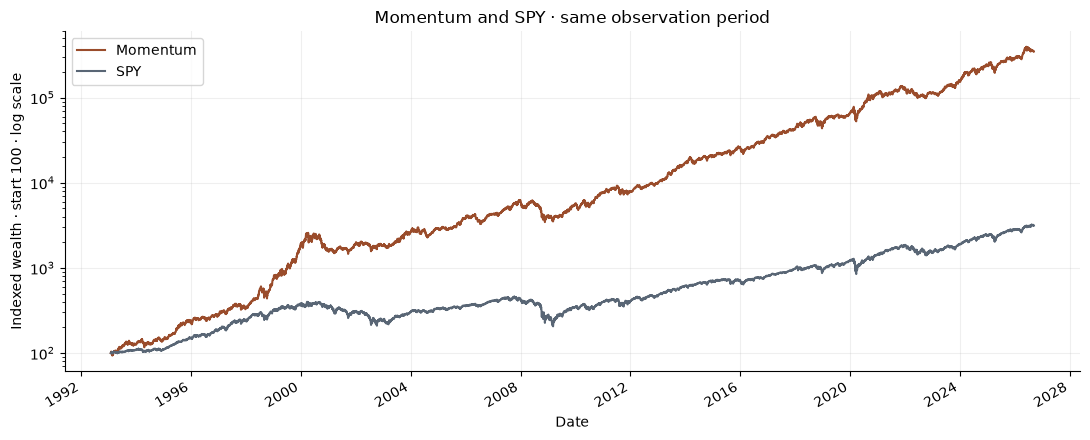

In [9]:
ax = indexed.rename(columns={'MOMENTUM': 'Momentum', 'SPY': 'SPY'}).plot(logy=True, color=['#9a4c2b', '#596675'])
ax.set(title='Momentum and SPY · same observation period', ylabel='Indexed wealth · start 100 · log scale', xlabel='Date')
plt.tight_layout()
plt.show()

## 13. Drawdown

A drawdown describes a loss from a previous peak, including an immediate first-day decline. Its minimum answers how deep the worst historical fall was. It does not tell us how likely an equally deep or deeper future loss might be.

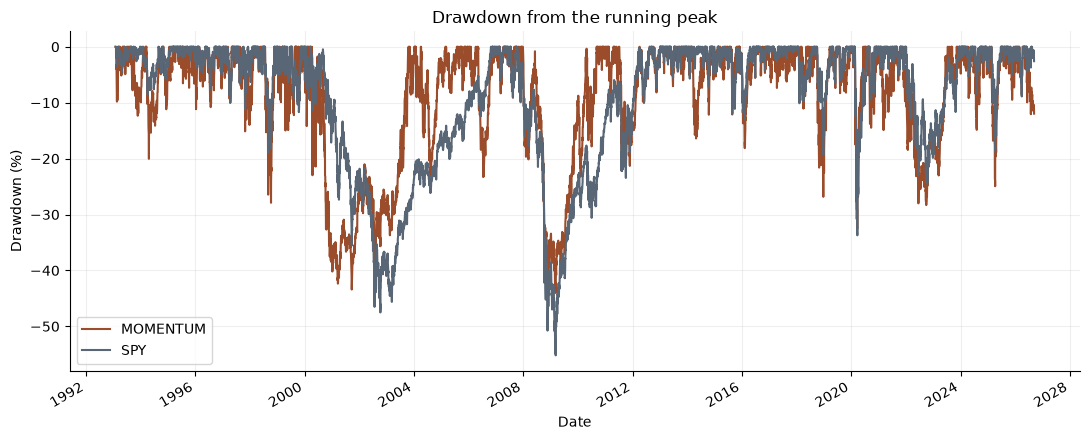

In [10]:
ax = (drawdowns * 100).plot(color=['#9a4c2b', '#596675'])
ax.set(title='Drawdown from the running peak', ylabel='Drawdown (%)', xlabel='Date')
plt.tight_layout()
plt.show()

## 14. Calendar-year comparison

Compound daily returns within each year. The first and final years are partial and clearly labelled; do not compare them as if they were complete years. Best and worst year labels use full calendar years only.

,MOMENTUM,SPY,coverage,first_return,last_return
1993,0.268159,0.087091,Partial first year,1993-02-01,1993-12-31
1994,0.143520,0.003973,Full calendar year,1994-01-03,1994-12-30
1995,0.682665,0.380489,Full calendar year,1995-01-03,1995-12-29
1996,0.128906,0.224976,Full calendar year,1996-01-02,1996-12-31
1997,0.266664,0.334751,Full calendar year,1997-01-02,1997-12-31
1998,1.105077,0.286925,Full calendar year,1998-01-02,1998-12-31
1999,1.603719,0.203894,Full calendar year,1999-01-04,1999-12-31
2000,-0.141683,-0.097416,Full calendar year,2000-01-03,2000-12-29
2001,0.167650,-0.117585,Full calendar year,2001-01-02,2001-12-31
2002,-0.054519,-0.215847,Full calendar year,2002-01-02,2002-12-31


,best_year,best_year_return,worst_year,worst_year_return
MOMENTUM,1999,1.603719,2008,-0.339707
SPY,1995,0.380489,2008,-0.367950


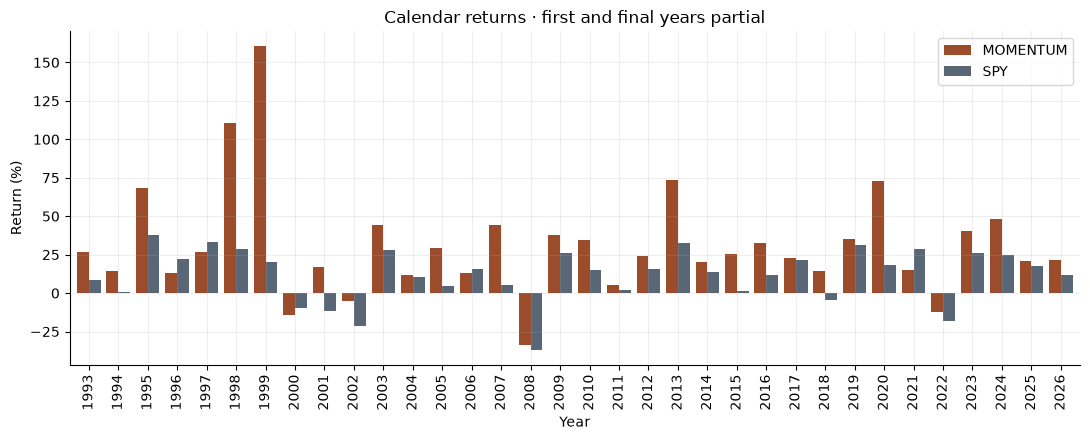

In [11]:
annual = calendar_returns(returns)
full_years = annual.loc[annual['coverage'] == 'Full calendar year']
best_worst = pd.DataFrame({name: {
    'best_year': full_years[name].idxmax(), 'best_year_return': full_years[name].max(),
    'worst_year': full_years[name].idxmin(), 'worst_year_return': full_years[name].min(),
} for name in returns}).T
best_worst[['best_year_return', 'worst_year_return']] = best_worst[['best_year_return', 'worst_year_return']].astype(float)
display(annual)
display(best_worst)
ax = (annual[['MOMENTUM', 'SPY']] * 100).plot.bar(color=['#9a4c2b', '#596675'], width=0.8)
ax.set(title='Calendar returns · first and final years partial', ylabel='Return (%)', xlabel='Year')
plt.tight_layout()
plt.show()

## 15. Holdings and turnover diagnostics

**One-way turnover** is half the sum of absolute differences between new target weights and actual pretrade weights after the previous month's price drift, including cash. A full switch between disjoint portfolios is 100%. Initial cash-to-stock allocation is 100% and is excluded from the average recurring turnover. This measure includes resizing retained companies, not just counting entrants. It is not a transaction-cost estimate.

The final partial month has a real formation rebalance, so that trade contributes to turnover. Selection frequency counts evaluation months, not an investment recommendation.

In [12]:
recurring = rebalances.loc[~rebalances['initial_allocation']]
diagnostics = pd.DataFrame([{
    'holding_months': len(rebalances), 'recurring_rebalances': len(recurring),
    'mean_turnover': recurring['turnover'].mean(), 'median_turnover': recurring['turnover'].median(),
    'max_turnover': recurring['turnover'].max(), 'initial_turnover': rebalances['turnover'].iloc[0],
    'mean_entrants': recurring['entrants'].mean(), 'unique_selected': holdings['ticker'].nunique(),
    'min_eligible': rebalances['eligible_companies'].min(), 'max_eligible': rebalances['eligible_companies'].max(),
    'missing_quote_events': len(missing_events),
}], index=['MOMENTUM'])
holding_frequency = holdings.groupby('ticker').size().rename('months_selected').to_frame()
holding_frequency['fraction_of_months'] = holding_frequency['months_selected'] / len(rebalances)
holding_frequency = holding_frequency.sort_values(['months_selected'], ascending=False, kind='stable')
display(diagnostics.T)
display(holding_frequency.head(10))
display(rebalances.tail(12))

,MOMENTUM
holding_months,404.000000
recurring_rebalances,403.000000
mean_turnover,0.229402
median_turnover,0.217480
max_turnover,0.540683
initial_turnover,1.000000
mean_entrants,2.109181
unique_selected,50.000000
min_eligible,31.000000
max_eligible,50.000000


,months_selected,fraction_of_months
ticker,,
NVDA,173,0.428218
AAPL,171,0.423267
NFLX,159,0.393564
AMD,148,0.366337
AMZN,143,0.353960
CAT,123,0.304455
UNH,120,0.297030
INTU,111,0.274752
AMGN,108,0.267327


,first_return,last_return,observations,holdings,turnover,entrants,initial_allocation,partial_month,eligible_companies
rebalance_date,,,,,,,,,
2025-09-30,2025-10-01,2025-10-31,23,10,0.216816,2,False,False,50
2025-10-31,2025-11-03,2025-11-28,19,10,0.313753,3,False,False,50
2025-11-28,2025-12-01,2025-12-31,22,10,0.312517,3,False,False,50
2025-12-31,2026-01-02,2026-01-30,20,10,0.115649,1,False,False,50
2026-01-30,2026-02-02,2026-02-27,19,10,0.214808,2,False,False,50
2026-02-27,2026-03-02,2026-03-31,22,10,0.141046,1,False,False,50
2026-03-31,2026-04-01,2026-04-30,21,10,0.108952,1,False,False,50
2026-04-30,2026-05-01,2026-05-29,20,10,0.233725,2,False,False,50
2026-05-29,2026-06-01,2026-06-30,21,10,0.136938,1,False,False,50


## 16. One rebalance, from raw prices to return

Use the **first evaluated rebalance**, chosen by position rather than performance. The table includes all eligible companies, their two raw adjusted-price endpoints, the resulting signal, the deterministic rank, the target weight, and the following period's endpoint return. Only the top ten receive nonzero weights. Next-month outcomes are attached after selection for this audit; they never influence ranks.

The sum of selected weights times endpoint returns must equal the compounded daily portfolio return for that month. This is an independent way to check that weights drift inside a month.

In [13]:
example_date = rebalances.index[0]
example_position = monthly.index.get_loc(example_date)
example_base = monthly.index[example_position - 12]
example_end = pd.Timestamp(rebalances.iloc[0]['last_return'])
example_signal = (prices.loc[example_date, companies] / prices.loc[example_base, companies] - 1)
example_signal = example_signal.loc[signals.loc[example_date].notna()].sort_index().sort_values(ascending=False, kind='stable')
walkthrough = pd.DataFrame(index=example_signal.index)
walkthrough['lookback_date'] = str(example_base.date())
walkthrough['rebalance_date'] = str(example_date.date())
walkthrough['holding_end'] = str(example_end.date())
walkthrough['lookback_price'] = prices.loc[example_base, walkthrough.index]
walkthrough['formation_price'] = prices.loc[example_date, walkthrough.index]
walkthrough['signal'] = example_signal
walkthrough['rank'] = np.arange(1, len(walkthrough) + 1)
walkthrough['weight'] = weights.loc[example_date, walkthrough.index]
walkthrough['next_period_return'] = prices.loc[example_end, walkthrough.index] / prices.loc[example_date, walkthrough.index] - 1
walkthrough['contribution'] = walkthrough['weight'] * walkthrough['next_period_return']
manual_month_return = walkthrough.loc[walkthrough['weight'] > 0, 'contribution'].sum()
computed_month_return = monthly_returns.loc[str(example_date.to_period('M') + 1), 'MOMENTUM']
np.testing.assert_allclose(manual_month_return, computed_month_return, rtol=1e-10, atol=1e-13)
display(walkthrough)
print(f'Raw endpoint check: {manual_month_return:.12%}; compounded daily result: {computed_month_return:.12%}')

,lookback_date,rebalance_date,holding_end,lookback_price,formation_price,signal,rank,weight,next_period_return,contribution
CSCO,1992-01-31,1993-01-29,1993-02-26,0.334497,0.788099,1.356075,1,0.1,-0.008475,-0.000847
ORCL,1992-01-31,1993-01-29,1993-02-26,0.362689,0.637156,0.756757,2,0.1,0.007692,0.000769
HD,1992-01-31,1993-01-29,1993-02-26,3.796257,6.031265,0.588740,3,0.1,-0.023033,-0.002303
UNH,1992-01-31,1993-01-29,1993-02-26,1.984110,3.075660,0.550146,4,0.1,-0.313953,-0.031395
TXN,1992-01-31,1993-01-29,1993-02-26,1.243603,1.913304,0.538517,5,0.1,0.046297,0.004630
JPM,1992-01-31,1993-01-29,1993-02-26,3.437088,5.160848,0.501518,6,0.1,-0.003076,-0.000308
DIS,1992-01-31,1993-01-29,1993-02-26,8.084549,10.868369,0.344338,7,0.1,-0.027397,-0.002740
BAC,1992-01-31,1993-01-29,1993-02-26,4.347486,5.500038,0.265108,8,0.1,-0.004651,-0.000465
PEP,1992-01-31,1993-01-29,1993-02-26,6.863939,8.636245,0.258205,9,0.1,-0.047761,-0.004776
QCOM,1992-01-31,1993-01-29,1993-02-26,0.447409,0.549940,0.229167,10,0.1,0.067796,0.006780


Raw endpoint check: -3.065613228444%; compounded daily result: -3.065613228444%


## 17. Difficult-period behaviour

Reuse notebook 01's three pre-existing historical stress windows. These are selected historical episodes, not a complete stress model. Each window starts again from wealth 1 on the previous observed date; both portfolios use the same return dates. Results are period returns and within-window drawdowns, not annualised estimates. No strategy settings change in these periods.

In [14]:
stress_windows = {'Global Financial Crisis': ('2007-10-01', '2009-03-31'),
                  'COVID Crash': ('2020-02-01', '2020-04-30'),
                  '2022 Selloff': ('2022-01-01', '2022-12-31')}
stress_rows = []
for label, (start, end) in stress_windows.items():
    window_returns = returns.loc[start:end]
    window_wealth = wealth_from_returns(window_returns, previous_observation(prices.index, window_returns.index[0]))
    for entity in returns:
        stress_rows.append({'id': label + ' / ' + entity, 'scenario': label, 'entity': entity,
                            'first_return': str(window_returns.index[0].date()), 'last_return': str(window_returns.index[-1].date()),
                            'observations': len(window_returns), 'total_return': window_wealth[entity].iloc[-1] - 1,
                            'max_drawdown': (window_wealth[entity] / window_wealth[entity].cummax() - 1).min()})
stress = pd.DataFrame(stress_rows).set_index('id')
display(stress)

,scenario,entity,first_return,last_return,observations,total_return,max_drawdown
id,,,,,,,
Global Financial Crisis / MOMENTUM,Global Financial Crisis,MOMENTUM,2007-10-01,2009-03-31,378,-0.293346,-0.450157
Global Financial Crisis / SPY,Global Financial Crisis,SPY,2007-10-01,2009-03-31,378,-0.459614,-0.551895
COVID Crash / MOMENTUM,COVID Crash,MOMENTUM,2020-02-03,2020-04-30,62,0.033239,-0.325123
COVID Crash / SPY,COVID Crash,SPY,2020-02-03,2020-04-30,62,-0.091822,-0.337173
2022 Selloff / MOMENTUM,2022 Selloff,MOMENTUM,2022-01-03,2022-12-30,251,-0.119971,-0.242908
2022 Selloff / SPY,2022 Selloff,SPY,2022-01-03,2022-12-30,251,-0.181754,-0.244964


## 18. Results summary

The following text is generated from the computed tables, so it cannot retain stale figures from another run. Compare compound return and risk together, and read the limitations before interpreting a performance gap.

In [15]:
a, b = summary.loc['MOMENTUM'], summary.loc['SPY']
display(Markdown(
    f"From **{returns.index[0].date()} to {returns.index[-1].date()}**, the strategy's CAGR was **{a.cagr:.2%}** "
    f"versus **{b.cagr:.2%}** for SPY. Annualised volatility was **{a.volatility:.2%}** versus **{b.volatility:.2%}**, "
    f"Sharpe **{a.sharpe:.2f}** versus **{b.sharpe:.2f}**, and maximum drawdown **{a.max_drawdown:.2%}** versus **{b.max_drawdown:.2%}**. "
    f"Average recurring one-way turnover was **{diagnostics.loc['MOMENTUM', 'mean_turnover']:.2%}**. "
    "These are descriptive, gross-of-cost results from a retrospectively selected company universe."
))

From **1993-02-01 to 2026-09-10**, the strategy's CAGR was **27.46%** versus **10.80%** for SPY. Annualised volatility was **24.72%** versus **18.54%**, Sharpe **1.01** versus **0.52**, and maximum drawdown **-45.02%** versus **-55.19%**. Average recurring one-way turnover was **22.94%**. These are descriptive, gross-of-cost results from a retrospectively selected company universe.

## 19. Limitations

1. **Survivorship and selection bias:** today's chosen 50 companies are projected backward. Failed, delisted, and unselected companies are absent. This is not a point-in-time investable universe and can substantially overstate historical performance.
2. **Frictionless baseline:** transaction costs, taxes, spreads, slippage and market impact are zero. Turnover shows trading activity, not its net cost.
3. **One specified experiment:** twelve months, ten stocks, no skipped month or tuning. No hypothesis test, statistical significance claim, or independent out-of-sample test establishes predictive power.
4. **Listing and history differences:** eligibility expands over time. Early portfolios choose from fewer companies and may have concentrated sector exposure.
5. **Provider and corporate actions:** frozen adjusted prices can contain errors, later revisions, ticker-history issues and imperfect distribution adjustments. Adjusted prices are not a historically vintage database. Internal arithmetic checks do not independently certify prices.
6. **Monthly simplification:** formation-close signal and execution share an idealized price; real orders cannot be assumed to obtain it after observing it. Adjusted-unit holding assumes the provider's distribution reinvestment convention. Missing held quotes trigger a severe write-off convention, not a measured delisting recovery.
7. **Descriptive risk estimates:** the preserved ^IRX conversion is approximate. Beta, correlation and volatility depend on the period and can change.
8. **Partial periods and historical scope:** the first year and final year/month are incomplete. Historical crises are examples, not all possible future shocks. Historical performance does not forecast future results.

Background: the [SEC investor bulletin on performance claims](https://www.investor.gov/introduction-investing/general-resources/news-alerts/alerts-bulletins/investor-bulletins-47) explains why historical performance presentations require context.

## 20. Conclusion and reviewed outputs

This experiment answers a narrow descriptive question: a fixed ranking rule produces a historical return path that can be compared with SPY on matching dates. It demonstrates data preparation, eligibility, information timing, portfolio accounting and risk measurement. It does not establish that the strategy is suitable for anyone or will work in the future.

To trace the result, start with the rebalance walkthrough in section 16. Follow the price history into the signal, selection, drifting holdings and next-month returns, then review the measurement assumptions and universe limitations.

The final cell independently verifies signals, ranks, returns and metrics, then saves structured tables and provenance. The dashboard reads those reviewed tables, not images or notebook display text.

In [16]:
# Chart sampling selects existing observations only. Keep initial/final dates,
# observed month ends, and each year's deepest daily drawdown for both series.
chart_dates = set(wealth.groupby(wealth.index.to_period('M')).tail(1).index)
chart_dates.update([wealth.index[0], wealth.index[-1]])
for _, year_drawdowns in drawdowns.groupby(drawdowns.index.year):
    chart_dates.update(year_drawdowns.idxmin().tolist())
chart_indexed = indexed.loc[sorted(chart_dates)]
chart_drawdowns = drawdowns.loc[sorted(chart_dates)]

momentum_methodology = [
    {'id': 'momentum-rule', 'title': 'Momentum Strategy — definition', 'detail':
     'Fixed 50-company universe from notebook 01; monthly trailing 12-month adjusted-price total return including the latest month; top 10 eligible companies, 10% target weight each, no skipped month or parameter tuning. Exact ties use alphabetical ticker order. Fixed adjusted units are held through the following month, so weights drift between monthly rebalances.'},
    {'id': 'momentum-timing', 'title': 'Momentum Strategy — eligibility and timing', 'detail':
     'Use exact final observed prices of completed months, not last nonmissing quotes. Require 13 valid month-end prices and complete positive daily prices across the trailing year. Eligibility and rank use only information dated at or before formation. Assume frictionless allocation at the formation close and earn returns strictly afterward. Same-close signal and execution is a monthly idealization, not an executable fill guarantee. SPY must be observed at the initial formation close.'},
    {'id': 'momentum-missing', 'title': 'Momentum Strategy — missing observations', 'detail':
     'No asset-price forward fill or hindsight replacement. At the first invalid held quote, mark that position to zero and keep it there for the remainder of the month. This is a severe fallback, not a measured delisting return. Missing SPY prices, complete portfolio loss, or fewer than ten eligible stocks after inception stop the run. The final incomplete month contributes observed returns using the previous signal.'},
    {'id': 'momentum-metrics', 'title': 'Momentum Strategy — metrics and turnover', 'detail':
     f"Identical daily returns from {returns.index[0].date()} through {returns.index[-1].date()}; initial wealth 1 on {initial_date.date()}. Total return, daily mean × 252, calendar-time CAGR, sample daily volatility × square root of 252, covariance beta and Pearson correlation are calculated in Python. Sharpe uses the same aligned ^IRX transformation, same-date yield and asset-volatility denominator as notebook 01. Maximum drawdown includes initial wealth. One-way turnover is half the absolute target-minus-drifted-weight changes including cash; its recurring mean excludes initial allocation. Best/worst calendar years exclude partial years."},
    {'id': 'momentum-limits', 'title': 'Momentum Strategy — limitations', 'detail':
     'Present-day universe survivorship and selection bias; changing listing/history eligibility; no transaction costs, taxes, slippage or market impact; provider and corporate-action limitations; monthly close execution and distribution-reinvestment simplifications; no independent out-of-sample evidence or tuning. Historical performance is not a forecast or a claim of investment suitability.'},
]
verification = write_outputs(globals())
display(pd.Series({k: v for k, v in verification.items() if k not in ['checks', 'manual_checks', 'missing_selected_quote_events']}))
print('Verified checks:', '; '.join(verification['checks']))

status                                                           verified
checked_at                               2026-09-12T14:54:28.560338+00:00
initial_wealth_date                                            1993-01-29
first_return                                                   1993-02-01
last_return                                                    2026-09-10
return_observations                                                  8460
holding_months                                                        404
first_signal_with_ten_eligible                                 1981-01-30
first_evaluated_signal                                         1993-01-29
last_evaluated_signal                                          2026-08-31
risk_free_forward_fills_in_evaluation                                  21
dtype: object

Verified checks: all eligible signals independently recalculated from raw prices; 12 complete months before first signal; top ten, deterministic ranks, unique holdings and unit weights; formation close strictly precedes every earned return; every monthly buy-and-hold endpoint reconciles; identical uninterrupted strategy and SPY daily grid; notebook 01 risk-free transformation and alignment; explicit initial wealth and first-return drawdown; independent NumPy performance identities
